# Data Preparation

## Setup

In [1]:
import os

In [2]:
import math

In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd

In [4]:
import xarray as xr

In [5]:
import rioxarray as rxr

In [6]:
import rasterio

In [7]:
from rasterio.transform import from_origin

In [8]:
from rasterio import features

In [9]:
from rasterio.warp import calculate_default_transform, reproject, Resampling

In [10]:
from pyproj import Transformer

In [11]:
from shapely.geometry import box, MultiPolygon, Polygon, Point

In [12]:
import mgrs

In [13]:
from scipy.ndimage import gaussian_filter, distance_transform_edt

In [14]:
DATA_DIR = '../data'

In [15]:
def tileId_to_epsg(tileId):
    zone = int(tileId[:2])
    return f'EPSG:326{zone}'

## Load habitat data

In [16]:
seagrass_fp = os.path.join(DATA_DIR, 'OSPAR2022PointsZm_group/OSPAR2022PointsZm_group.shp')

In [17]:
seagrass_gdf = gpd.read_file(seagrass_fp)

In [18]:
seagrass_gdf.head()

,Join_Count,TARGET_FID,GUI,RecordKey,HabType,HabSubType,HabStatus,Certainty,Determiner,DetDate,...,DataOwner,Accuracy,Latitude,Longitude,AltHabType,AltHabClas,AltHabRel,FEATURE_ID,tileId,geometry
0,1,16,OSPARHab2010IE1v0,10100024,Zostera beds,Zostera marina beds,Present,Certain,JH Allen,2003-06-13,...,Trinity College Dublin,None,52.264474,-9.825030,None,None,None,1145,29UMT,POINT (-9.82503 52.26447)
1,1,39,OSPARHab2010IE1v0,10100098,Zostera beds,Zostera marina beds,Present,Certain,JH Allen,2003-06-13,...,Trinity College Dublin,None,51.691969,-8.507860,None,None,None,1144,29UNT,POINT (-8.50786 51.69197)
2,1,41,OSPARHab2010IE1v0,10100099,Zostera beds,Zostera marina beds,Present,Certain,JH Allen,2003-06-13,...,Trinity College Dublin,None,54.962370,-8.493598,None,None,None,1124,29UNA,POINT (-8.4936 54.96237)
3,1,42,OSPARHab2010IE1v0,10100100,Zostera beds,Zostera marina beds,Present,Certain,JH Allen,2003-06-13,...,Trinity College Dublin,None,54.993900,-8.491816,None,None,None,1125,29UNA,POINT (-8.49182 54.9939)
4,1,46,OSPARHab2010IE1v0,10100092,Zostera beds,Zostera marina beds,Present,Certain,JH Allen,2003-06-13,...,Trinity College Dublin,None,52.268341,-9.997605,None,None,None,1139,29UMT,POINT (-9.9976 52.26834)


In [19]:
# def latlon_to_mgrs_tile(lat, lon):
#     try:
#         m = mgrs.MGRS()
#         mgrs_code = m.toMGRS(lat, lon, MGRSPrecision=2)
#         tile = mgrs_code[:5]
#         return tile
#     except Exception as e:
#         print(f'Error computing MGRS for point {lat}, {lon}')
#         raise

In [20]:
# seagrass_gdf['tileId'] = seagrass_gdf.apply(lambda row: latlon_to_mgrs_tile(row.geometry.y, row.geometry.x), axis=1)

In [20]:
# seagrass_gdf.to_file(seagrass_fp)

## Load Sentinel-2 data

Load all files

In [19]:
polymer_dir = os.path.join(DATA_DIR, 's2_processed')

In [22]:
data_tiles_all = {}

for f in os.listdir(polymer_dir):
    if not f.startswith('polymer'):
        continue

    tile_id = f[8:13]

    f_full = os.path.join(polymer_dir, f)
    
    data_tiles_all[tile_id] = xr.open_dataset(f_full)

In [24]:
def fix_polymer_coords(poly_ds, tileId):
    dst_crs = tileId_to_epsg(tileId)
    
    transformer = Transformer.from_crs('EPSG:4326', dst_crs, always_xy=True)
    latitudes = poly_ds['latitude'].values.ravel()
    longitudes = poly_ds['longitude'].values.ravel()
    ny, nx = poly_ds.sizes['height'], poly_ds.sizes['width']
    easting_1d, northing_1d = transformer.transform(longitudes, latitudes)
    easting_2d = easting_1d.reshape((ny, nx)).round()
    northing_2d = northing_1d.reshape((ny, nx)).round()

    fixed = poly_ds.rename({'height': 'y', 'width': 'x'})
    fixed = fixed.assign({
        'y': northing_2d[:,0],  # assuming rectilinear in dst_crs
        'x': easting_2d[0,:]
    })
    fixed.rio.write_crs(dst_crs, inplace=True)

    return fixed

In [25]:
for tileId, ds in data_tiles_all.items():
    print(f"Processing {tileId}")
    data_tiles_all[tileId] = fix_polymer_coords(ds, tileId)

Processing 29VPD


Load existing data tiles to modify

In [16]:
data_tiles_all = {}
data_tiles_dir = os.path.join(DATA_DIR, 'data_tiles')
for f in os.listdir(data_tiles_dir):
    if not f.startswith('data_tile'):
        continue

    tile_id = f[10:15]

    f_full = os.path.join(data_tiles_dir, f)
    
    ds = xr.open_dataset(f_full)
    
    if 'PercGravel' not in ds.data_vars:
        ds.close()
        continue

    data_tiles_all[tile_id] = ds
    tile_crs = tileId_to_epsg(tile_id)
    data_tiles_all[tile_id].rio.write_crs(tile_crs, inplace=True)

In [17]:
data_tiles_all['30UUA']

<xarray.Dataset> Size: 3GB
Dimensions:      (y: 3599, x: 5490)
Coordinates:
  * y            (y) float64 29kB 5.6e+06 5.6e+06 ... 5.528e+06 5.528e+06
  * x            (x) float64 44kB 3e+05 3e+05 3e+05 ... 4.098e+05 4.098e+05
    spatial_ref  int64 8B 0
Data variables: (12/27)
    latitude     (y, x) float64 158MB ...
    longitude    (y, x) float64 158MB ...
    bitmask      (y, x) float32 79MB ...
    Rnir         (y, x) float32 79MB ...
    Rgli         (y, x) float32 79MB ...
    logchl       (y, x) float32 79MB ...
    ...           ...
    WavesKE      (y, x) float32 79MB ...
    Substrate    (y, x) float64 158MB ...
    PercGravel   (y, x) float32 79MB ...
    PercMud      (y, x) float32 79MB ...
    PercSand     (y, x) float32 79MB ...
    NE_Subtidal  (y, x) float64 158MB ...
Attributes: (12/57)
    sensor:                MSI
    dir_static:            /home/olley/packages/polymer-master/polymer_auxdata
    dir_common:            /home/olley/packages/polymer-master/polymer_auxdat...
    thres_Rcloud:          0.2
    thres_Rcloud_std:      0.04
    force_initialization:  False
    ...                    ...
    processing_duration:   0:11:54.572639
    l1_filename:           ../data/s2_processed/30UUA/subset-30UUA.nc
    start_time:            2020-06-23 11:21:19
    stop_time:             2020-06-23 11:21:19
    l2_filename:           ../data/s2_processed/30UUA/polymer-30UUA.nc
    l2_format:             NETCDF4_CLASSIC

## Load bathymetry data

In [22]:
# regions = ['be_de', 'denmark', 'fr_be', 'FRwest', 'ireland', 'UKnorth', 'UKsouth']
regions = ['UKnorth', 'UKsouth']

In [23]:
bathy_fp = os.path.join(DATA_DIR, 'bathymetry/EMODnet_bathymetry_{region}.nc')

In [24]:
bathy_all = {}
for region in regions:
    bathy = xr.open_dataset(bathy_fp.format(region=region))
    bathy.rio.write_crs('EPSG:4326', inplace=True)
    bathy_all[region] = bathy['elevation']

In [25]:
def add_bathymetry_to_tile(ds, tileId):
    bathy_proj_list = []
    
    for region, bathy in bathy_all.items():
        try:
            bathy_aligned = bathy.rio.reproject_match(ds, resampling=Resampling.bilinear)
            if bathy_aligned.notnull().values.any():
                mask = np.isnan(bathy_aligned.values)
                _, indices = distance_transform_edt(
                    mask,
                    return_indices=True
                )
                bathy_aligned = bathy_aligned.copy(data=bathy_aligned.values[tuple(indices)])
                bathy_proj_list.append(bathy_aligned)
        except Exception as e:
            print(f"Tile {tileId}: skipping {region} bathymetry due to {e}")
            raise(e)

    if not bathy_proj_list:
        print(f"No bathymetry overlap found for tile {tileId}")
        return ds

    # merge bathymetries
    bathy_final = bathy_proj_list[0]
    for other in bathy_proj_list[1:]:
        bathy_final = bathy_final.combine_first(other)

    # add as band
    ds['bathymetry'] = bathy_final

In [26]:
for tileId, ds in data_tiles_all.items():
    print(f"Processing {tileId}")
    add_bathymetry_to_tile(ds, tileId)

Processing 29UPB
Processing 29UPR
Processing 29VPC
Processing 29VPE
Processing 30UUA
Processing 30UUB
Processing 30UUC
Processing 30UUD
Processing 30UUE
Processing 30UUF
Processing 30UUG
Processing 30UVA
Processing 30UVB
Processing 30UVC
Processing 30UVE
Processing 30UVF
Processing 30UWB
Processing 30UXB
Processing 30VUH
Processing 30VUJ
Processing 30VUK
Processing 30VVK
Processing 30VVL
Processing 30VWL
Processing 31UCS


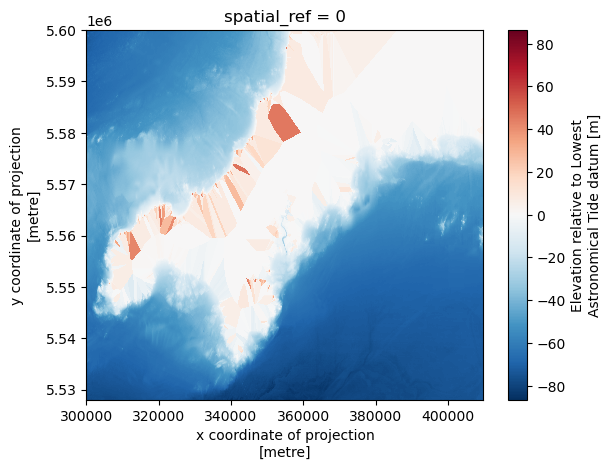

In [27]:
data_tiles_all['30UUA']['bathymetry'].plot()

## Load habitat survey KDE

In [32]:
kde_path = os.path.join(DATA_DIR, 'habitats_kernel.tif')

In [33]:
kde_da = rxr.open_rasterio(kde_path).squeeze('band', drop=True)

In [34]:
for tileId, ds in data_tiles_all.items():
    print(f"Processing {tileId}")
    kde_aligned = kde_da.rio.reproject_match(ds, resampling=Resampling.nearest)
    data_tiles_all[tileId]['SurveyKDE'] = kde_aligned

Processing 29VPD


## Wave Energy

In [28]:
waves_fp = os.path.join(DATA_DIR, 'ke_waves_NC_withconf/ke_waves_atlantic.tif')

In [29]:
waves_da = rxr.open_rasterio(waves_fp, masked=True).squeeze(drop=True)

In [30]:
waves_da[:] = xr.where(waves_da >= 150.0, 150.0, waves_da)

In [31]:
for tileId, ds in data_tiles_all.items():
    print(f"Processing {tileId}")
    waves_aligned = waves_da.rio.reproject_match(ds, resampling=Resampling.bilinear)
    mask = np.isnan(waves_aligned.values)
    _, indices = distance_transform_edt(
        mask,
        return_indices=True
    )
    waves_aligned = waves_aligned.copy(data=waves_aligned.values[tuple(indices)])
    data_tiles_all[tileId]['WavesKE'] = waves_aligned

Processing 29UPB
Processing 29UPR
Processing 29VPC
Processing 29VPE
Processing 30UUA
Processing 30UUB
Processing 30UUC
Processing 30UUD
Processing 30UUE
Processing 30UUF
Processing 30UUG
Processing 30UVA
Processing 30UVB
Processing 30UVC
Processing 30UVE
Processing 30UVF
Processing 30UWB
Processing 30UXB
Processing 30VUH
Processing 30VUJ
Processing 30VUK
Processing 30VVK
Processing 30VVL
Processing 30VWL
Processing 31UCS


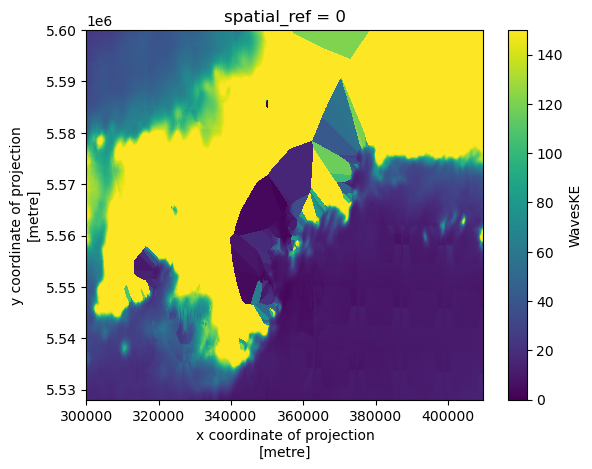

In [32]:
data_tiles_all['30UUA']['WavesKE'].plot()

## EUSeaMap substrate

In [39]:
substrate_fp = os.path.join(DATA_DIR, 'EUSeaMap_2023_Substrate/EUSeaMap_substrate.tif')

In [40]:
substrate_da = rxr.open_rasterio(substrate_fp).squeeze('band', drop=True)

In [41]:
substrate_da = substrate_da.astype(float)

In [42]:
substrate_da[:] = xr.where(substrate_da == float(substrate_da.attrs['_FillValue']), np.nan, substrate_da)

In [43]:
del substrate_da.attrs['_FillValue']

In [44]:
substrate_classes_fp = os.path.join(DATA_DIR, 'EUSeaMap_2023_Substrate/EUSeaMap_substrate_classes.csv')

In [48]:
substrate_classes = pd.read_csv(substrate_classes_fp)

In [46]:
for tileId, ds in data_tiles_all.items():
    print(f"Processing {tileId}")
    substrate_aligned = substrate_da.rio.reproject_match(ds, resampling=Resampling.nearest)
    data_tiles_all[tileId]['Substrate'] = substrate_aligned

Processing 29UPB
Processing 29UPR
Processing 29VPC
Processing 29VPE
Processing 30UUA
Processing 30UUB
Processing 30UUC
Processing 30UUD
Processing 30UUE
Processing 30UUF
Processing 30UUG
Processing 30UVA
Processing 30UVB
Processing 30UVC
Processing 30UVE
Processing 30UVF
Processing 30UWB
Processing 30UXA
Processing 30UXB
Processing 30VUH
Processing 30VUJ
Processing 30VUK
Processing 30VVK
Processing 30VVL
Processing 30VWL
Processing 31UCS
Processing 32UMF
Processing 32UNF
Processing 32UNG
Processing 32UPG
Processing 32VPK


In [50]:
substrate_map = zip(substrate_classes['Value'], substrate_classes['new_val'])
substrate_map = {float(k): float(v) for k, v in substrate_map}
substrate_map[np.nan] = 4.0

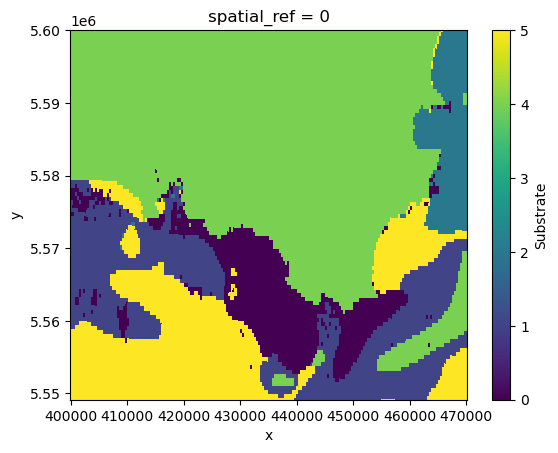

In [54]:
data_tiles_all['30UVA']['Substrate'].plot()

## BGS Predictive Seabed Sediments

In [38]:
perc_gravel_path = os.path.join(DATA_DIR, 'Predictive_SBS_UK_V1_ESRI/Predictive_perc_Gravel_UK_v1.tif')
perc_mud_path = os.path.join(DATA_DIR, 'Predictive_SBS_UK_V1_ESRI/Predictive_perc_Mud_UK_v1.tif')
perc_sand_path = os.path.join(DATA_DIR, 'Predictive_SBS_UK_V1_ESRI/Predictive_perc_Sand_UK_v1.tif')

In [39]:
perc_gravel_da = rxr.open_rasterio(perc_gravel_path, masked=True).squeeze(drop=True)
perc_mud_da = rxr.open_rasterio(perc_mud_path, masked=True).squeeze(drop=True)
perc_sand_da = rxr.open_rasterio(perc_sand_path, masked=True).squeeze(drop=True)

In [40]:
sediment_bands = {
    "PercGravel": perc_gravel_da,
    "PercMud": perc_mud_da,
    "PercSand": perc_sand_da
}

In [42]:
for tileId, ds in data_tiles_all.items():
    print(f"Processing {tileId}")
    for name, da in sediment_bands.items():
        da_aligned = da.rio.reproject_match(ds, resampling=Resampling.bilinear)
        if not da_aligned.notnull().values.any():
            print(f"{tileId} does not overlap with input data")
            break
        mask = np.isnan(da_aligned.values)
        _, indices = distance_transform_edt(
            mask,
            return_indices=True
        )
        da_aligned = da_aligned.copy(data=da_aligned.values[tuple(indices)])
        da_aligned = da_aligned.copy(data=gaussian_filter(da_aligned.values, sigma=6.0))
        ds[name] = da_aligned

Processing 29UPB
Processing 29UPR
Processing 29VPC
Processing 29VPE
Processing 30UUA
Processing 30UUB
Processing 30UUC
Processing 30UUD
Processing 30UUE
Processing 30UUF
Processing 30UUG
Processing 30UVA
Processing 30UVB
Processing 30UVC
Processing 30UVE
Processing 30UVF
Processing 30UWB
Processing 30UXB
Processing 30VUH
Processing 30VUJ
Processing 30VUK
Processing 30VVK
Processing 30VVL
Processing 30VWL
Processing 31UCS


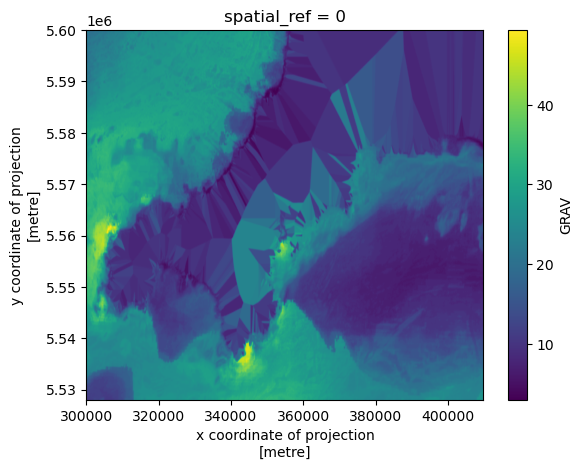

In [43]:
data_tiles_all['30UUA']['PercGravel'].plot()

In [51]:
data_tiles_all['30UUA']

<xarray.Dataset> Size: 2GB
Dimensions:      (y: 3599, x: 5490)
Coordinates:
  * y            (y) float64 29kB 5.6e+06 5.6e+06 ... 5.528e+06 5.528e+06
  * x            (x) float64 44kB 3e+05 3e+05 3e+05 ... 4.098e+05 4.098e+05
    spatial_ref  int64 8B 0
Data variables: (12/26)
    latitude     (y, x) float64 158MB ...
    longitude    (y, x) float64 158MB ...
    bitmask      (y, x) float32 79MB ...
    Rnir         (y, x) float32 79MB ...
    Rgli         (y, x) float32 79MB ...
    logchl       (y, x) float32 79MB ...
    ...           ...
    grid_id      (y, x) int32 79MB ...
    WavesKE      (y, x) float32 79MB 23.56 23.5 23.45 23.39 ... 14.38 14.4 14.42
    Substrate    (y, x) float64 158MB ...
    PercGravel   (y, x) float32 79MB 21.0 21.0 21.0 20.96 ... 26.14 26.06 26.19
    PercMud      (y, x) float32 79MB 3.0 3.0 3.0 3.0 3.0 ... 4.0 4.0 4.0 4.0 4.0
    PercSand     (y, x) float32 79MB 76.82 76.89 76.96 ... 69.86 69.94 69.81
Attributes: (12/57)
    sensor:                MSI
    dir_static:            /home/olley/packages/polymer-master/polymer_auxdata
    dir_common:            /home/olley/packages/polymer-master/polymer_auxdat...
    thres_Rcloud:          0.2
    thres_Rcloud_std:      0.04
    force_initialization:  False
    ...                    ...
    processing_duration:   0:11:54.572639
    l1_filename:           ../data/s2_processed/30UUA/subset-30UUA.nc
    start_time:            2020-06-23 11:21:19
    stop_time:             2020-06-23 11:21:19
    l2_filename:           ../data/s2_processed/30UUA/polymer-30UUA.nc
    l2_format:             NETCDF4_CLASSIC

## Habitat rasterization

In [49]:
seagrass_gdf = seagrass_gdf[seagrass_gdf['tileId'].isin(data_tiles_all.keys())]
seagrass_gdf = seagrass_gdf.reset_index()

In [50]:
def latlon_to_utm_vectorized(gdf, tileId_col='tileId'):
    utm_xs = np.full(len(gdf), np.nan)
    utm_ys = np.full(len(gdf), np.nan)

    # group rows by tileId
    for tileId, group in gdf.groupby(tileId_col):
        # transformer for this tile
        dst_crs = tileId_to_epsg(tileId)
        transformer = Transformer.from_crs('EPSG:4326', dst_crs, always_xy=True)

        # extract lon/lat arrays
        lons = group.geometry.x.values
        lats = group.geometry.y.values

        # transform in one call (vectorized)
        xs, ys = transformer.transform(lons, lats)

        utm_xs[group.index] = xs
        utm_ys[group.index] = ys

    gdf['utm_x'] = utm_xs
    gdf['utm_y'] = utm_ys
    return gdf

In [51]:
seagrass_gdf = latlon_to_utm_vectorized(seagrass_gdf)

In [52]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

In [53]:
def gaussian_rasterize(df, template, sigma, band_name):
    x_idx = df.apply(lambda row: find_nearest(template.x.values, row.utm_x)[0], axis=1).values
    y_idx = df.apply(lambda row: find_nearest(template.y.values, row.utm_y)[0], axis=1).values
    arr = np.zeros((template.sizes['y'], template.sizes['x']), dtype='uint8')
    arr[y_idx, x_idx] = 1
    dist = distance_transform_edt(1 - arr)
    normalized = np.exp(-(dist**2) / (2 * sigma**2))
    normalized[y_idx, x_idx] = 1.0

    da = xr.DataArray(
        normalized,
        dims=('y', 'x'),
        coords={'y': template.y, 'x': template.x},
        name=band_name
    )
    da.rio.write_crs(template.rio.crs, inplace=True)

    return da

In [54]:
for tileId, group in seagrass_gdf.groupby('tileId'):
    print(f"Processing {tileId}")
    gaussian_da = gaussian_rasterize(group, data_tiles_all[tileId], 2.0, 'ZM_Gauss')
    data_tiles_all[tileId] = data_tiles_all[tileId].assign({'ZM_Gauss': gaussian_da})

Processing 29VPD


## Subtiling

In [55]:
land_fp = os.path.join(DATA_DIR, 'simplified-land-polygons-complete-3857/simplified_land_polygons.shp')
land_polys = gpd.read_file(land_fp)

In [56]:
def min_max_round(array, step_size):
    res = np.zeros(4)
    res[0] = int(math.floor(array[0] / step_size)) * step_size
    res[1] = int(math.floor(array[1] / step_size)) * step_size
    res[2] = int(math.ceil(array[2] / step_size)) * step_size
    res[3] = int(math.ceil(array[3] / step_size)) * step_size
    return res

In [57]:
# Sentinel-2 Sub-tile Size in EPSG:32630
STEP_SIZE = 10000  # 10.0 km in meters

def create_epsg_grid(polygon, land_df, crs):
    """
    Generate a regular grid covering for a polygon in a given CRS.
    
    :param polygon: Shapely Polygon (buffered coastline)
    :param land_df: Land DataFrame
    :param crs: Target coordinate reference system
    :return: List of intersecting tile bounding boxes
    """
    # Reproject polygon to EPSG:32630
    geometry = polygon.geometry.iloc[0]
    if isinstance(geometry, MultiPolygon):
        polygons = list(geometry.geoms)
    else:
        polygons = geometry
    
    gdf_polygons = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326").to_crs(crs)
    polygons_utm = list(gdf_polygons.geometry)

    # Get bounds in UTM coordinates
    minx, miny, maxx, maxy = min_max_round(gdf_polygons.total_bounds, step_size=STEP_SIZE)

    # Generate grid cells at Sentinel-2 tile resolution
    grid_boxes = []
    x_coords = np.arange(minx, maxx, STEP_SIZE)
    y_coords = np.arange(miny, maxy, STEP_SIZE)

    for x in x_coords:
        for y in y_coords:
            tile = box(x, y, x + STEP_SIZE, y + STEP_SIZE)

            # Check if tile intersects the coastline polygon
            if any(p.intersects(tile) for p in polygons_utm):
                # Exclude tiles that are entirely on land
                tile_gdf = gpd.GeoDataFrame(
                    geometry=[tile], crs=crs
                ).to_crs(land_df.crs)
                
                if not land_df.contains(tile_gdf.iloc[0].geometry).any():
                    grid_boxes.append(tile)

    return gpd.GeoDataFrame(geometry=grid_boxes, crs=crs)

In [58]:
def add_grid_band(ds, grid_boxes, band_name='grid_id'):
    if grid_boxes.crs != ds.rio.crs:
        grid_boxes = grid_boxes.to_crs(ds.rio.crs)

    grid_boxes = grid_boxes.reset_index(drop=True)
    grid_boxes['grid_id'] = grid_boxes.index + 1

    rasterized = features.rasterize(
        [(geom, value) for geom, value in zip(grid_boxes.geometry, grid_boxes['grid_id'])],
        out_shape=ds.rio.shape,
        transform=ds.rio.transform(),
        fill=0,  # background = 0 (no grid)
        dtype='int32'
    )

    # Wrap as DataArray
    da = xr.DataArray(
        rasterized,
        dims=('y', 'x'),
        coords={'y': ds.y, 'x': ds.x},
        name=band_name
    )
    da.rio.write_crs(ds.rio.crs, inplace=True)

    ds[band_name] = da

In [59]:
for tileId, ds in data_tiles_all.items():
    print(f"Processing {tileId}")
    wkt_fp = os.path.join(DATA_DIR, f'coastline_buffer/Buffered_Coastline_{tileId}.wkt')
    if os.path.exists(wkt_fp):
        with open(wkt_fp, 'r') as f:
            wkt = f.read()
    else:
        print(f"Coastline buffer file for {tileId} does not exist.")
        continue
    
    poly = gpd.GeoSeries.from_wkt([wkt])

    grid_boxes = create_epsg_grid(poly, land_polys, ds.rio.crs)
    add_grid_band(ds, grid_boxes)

Processing 29VPD
Coastline buffer file for 29VPD does not exist.


In [69]:
# del data_tiles_all['29VPD']

## Save and restore

In [70]:
for tileId, ds in data_tiles_all.items():
    print(f"Saving {tileId}")
    save_fp = os.path.join(DATA_DIR, f'data_tiles/data_tile_{tileId}.nc')
    ds.to_netcdf(save_fp)

Saving 30UUB
Saving 30UXB
Saving 31UCS


In [66]:
data_tiles_all = {}
data_tiles_dir = os.path.join(DATA_DIR, 'data_tiles')
for f in os.listdir(data_tiles_dir):
    if not f.startswith('data_tile'):
        continue

    tile_id = f[10:15]

    f_full = os.path.join(data_tiles_dir, f)
    
    data_tiles_all[tile_id] = xr.open_dataset(f_full)
    tile_crs = tileId_to_epsg(tile_id)
    data_tiles_all[tile_id].rio.write_crs(tile_crs, inplace=True)

Modify existing

In [35]:
from netCDF4 import Dataset

In [44]:
new_vars = []
modify_vars = ['PercGravel', 'PercMud', 'PercSand']
# modify_vars = ['WavesKE', 'bathymetry']

In [45]:
for tileId, ds in data_tiles_all.items():
    print(f"Updating {tileId}")
    save_fp = os.path.join(DATA_DIR, f'data_tiles/data_tile_{tileId}.nc')
    ds.close()
    with Dataset(save_fp, 'a') as nc:
        for k in new_vars:
            if not hasattr(ds, k) or k in nc.variables:
                continue
            nc.createVariable(
                k,
                ds[k].dtype,
                ds[k].dims
            )
            nc[k][:] = ds[k].values

        for k in modify_vars:
            if not hasattr(ds, k):
                continue
            nc[k][:] = ds[k].values

Updating 29UPB
Updating 29UPR
Updating 29VPC
Updating 29VPE
Updating 30UUA
Updating 30UUB
Updating 30UUC
Updating 30UUD
Updating 30UUE
Updating 30UUF
Updating 30UUG
Updating 30UVA
Updating 30UVB
Updating 30UVC
Updating 30UVE
Updating 30UVF
Updating 30UWB
Updating 30UXB
Updating 30VUH
Updating 30VUJ
Updating 30VUK
Updating 30VVK
Updating 30VVL
Updating 30VWL
Updating 31UCS
